In [1]:
import io
import re
import zstandard as zstd

from pathlib import Path

import chess.pgn
import numpy as np
import pandas as pd

In [2]:
DATA_DIR = Path("data")

PGN_ZST_PATH = DATA_DIR / "lichess_db_april_2017_eval.pgn.zst"

MAX_GAMES = 50_000

In [3]:
# Small helpers for eval and clock parsing
EVAL_RE = re.compile(r"\[%eval\s+([^\]]+)\]")
CLK_RE = re.compile(r"\[%clk\s+([^\]]+)\]")

def parse_clock_seconds(clock_text):
  if clock_text is None:
    return np.nan

  parts = clock_text.strip().split(":")

  if len(parts) != 3:
    return np.nan

  hours, minutes, seconds = parts

  try:
    total = 3600 * int(hours)
    total += 60 * int(minutes)
    total += float(seconds)
    return total
  except ValueError:
    return np.nan
  
def parse_eval_cp(eval_text):
  if eval_text is None:
    return np.nan

  eval_text = eval_text.strip()

  if eval_text.startswith("#"):
    mate_text = eval_text.replace("#", "")

    try:
      mate = int(mate_text)
    except ValueError:
      return np.nan

    sign = 1 if mate > 0 else -1
    capped_mate_cp = 10_000 - 100 * abs(mate)

    return sign * capped_mate_cp

  try:
    return 100.0 * float(eval_text)
  except ValueError:
    return np.nan
  
def get_comment_eval(comment):
  match = EVAL_RE.search(comment)

  if match is None:
    return np.nan

  return parse_eval_cp(match.group(1))

def get_comment_clock(comment):
  match = CLK_RE.search(comment)

  if match is None:
    return np.nan

  return parse_clock_seconds(match.group(1))

In [4]:
def iter_pgn_games_zst(path, max_games=None):
  count = 0

  with open(path, "rb") as compressed:
    dctx = zstd.ZstdDecompressor()
    stream = dctx.stream_reader(compressed)

    text_stream = io.TextIOWrapper(
      stream,
      encoding="utf-8",
      errors="replace",
    )

    while True:
      game = chess.pgn.read_game(text_stream)

      if game is None:
        break

      yield game
      count += 1

      if max_games is not None and count >= max_games:
        break

In [5]:
def safe_int(value):
  try:
    return int(value)
  except (TypeError, ValueError):
    return np.nan

In [6]:
def result_to_scores(result):
  if result == "1-0":
    return 1.0, 0.0

  if result == "0-1":
    return 0.0, 1.0

  if result == "1/2-1/2":
    return 0.5, 0.5

  return np.nan, np.nan

In [7]:
def extract_game_metadata(game, game_id):
  headers = game.headers

  white_score, black_score = result_to_scores(headers.get("Result"))

  return {
    "game_id": game_id,
    "site": headers.get("Site"),
    "utc_date": headers.get("UTCDate"),
    "utc_time": headers.get("UTCTime"),
    "event": headers.get("Event"),
    "white": headers.get("White"),
    "black": headers.get("Black"),
    "white_elo": safe_int(headers.get("WhiteElo")),
    "black_elo": safe_int(headers.get("BlackElo")),
    "white_rating_diff": safe_int(headers.get("WhiteRatingDiff")),
    "black_rating_diff": safe_int(headers.get("BlackRatingDiff")),
    "result": headers.get("Result"),
    "white_score": white_score,
    "black_score": black_score,
    "eco": headers.get("ECO"),
    "opening": headers.get("Opening"),
    "time_control": headers.get("TimeControl"),
    "termination": headers.get("Termination"),
  }

In [8]:
def move_phase(ply):
  if ply <= 20:
    return "opening"

  if ply <= 60:
    return "middlegame"

  return "endgame"

In [9]:
def extract_move_rows(game, game_id):
  rows = []

  board = game.board()
  prev_eval_cp = np.nan
  node = game

  for ply, next_node in enumerate(game.mainline(), start=1):
    move = next_node.move
    mover_color = board.turn
    mover = "white" if mover_color == chess.WHITE else "black"

    san = board.san(move)
    board.push(move)

    comment = next_node.comment or ""
    eval_cp = get_comment_eval(comment)
    clock_seconds = get_comment_clock(comment)

    if np.isnan(prev_eval_cp) or np.isnan(eval_cp):
      eval_delta_cp = np.nan
      mover_loss_cp = np.nan
    else:
      eval_delta_cp = eval_cp - prev_eval_cp

      if mover == "white":
        mover_loss_cp = -eval_delta_cp
      else:
        mover_loss_cp = eval_delta_cp

      mover_loss_cp = max(0.0, mover_loss_cp)

    rows.append({
      "game_id": game_id,
      "ply": ply,
      "move_number": (ply + 1) // 2,
      "mover": mover,
      "san": san,
      "uci": move.uci(),
      "phase": move_phase(ply),
      "eval_cp": eval_cp,
      "prev_eval_cp": prev_eval_cp,
      "eval_delta_cp": eval_delta_cp,
      "mover_loss_cp": mover_loss_cp,
      "clock_seconds": clock_seconds,
    })

    prev_eval_cp = eval_cp
    node = next_node

  return rows

In [10]:
def parse_pgn_zst(path, max_games=None):
  game_rows = []
  move_rows = []

  for game_id, game in enumerate(iter_pgn_games_zst(path, max_games)):
    game_rows.append(extract_game_metadata(game, game_id))
    move_rows.extend(extract_move_rows(game, game_id))

    if game_id > 0 and game_id % 1000 == 0:
      print(f"Parsed {game_id:,} games")

  games_df = pd.DataFrame(game_rows)
  moves_df = pd.DataFrame(move_rows)

  return games_df, moves_df

In [11]:
games_df, moves_df = parse_pgn_zst(
  PGN_ZST_PATH,
  max_games=MAX_GAMES,
)

Parsed 1,000 games
Parsed 2,000 games
Parsed 3,000 games
Parsed 4,000 games
Parsed 5,000 games
Parsed 6,000 games
Parsed 7,000 games
Parsed 8,000 games
Parsed 9,000 games
Parsed 10,000 games
Parsed 11,000 games
Parsed 12,000 games
Parsed 13,000 games
Parsed 14,000 games
Parsed 15,000 games
Parsed 16,000 games
Parsed 17,000 games
Parsed 18,000 games
Parsed 19,000 games
Parsed 20,000 games
Parsed 21,000 games
Parsed 22,000 games
Parsed 23,000 games
Parsed 24,000 games
Parsed 25,000 games
Parsed 26,000 games
Parsed 27,000 games
Parsed 28,000 games
Parsed 29,000 games
Parsed 30,000 games
Parsed 31,000 games
Parsed 32,000 games
Parsed 33,000 games
Parsed 34,000 games
Parsed 35,000 games
Parsed 36,000 games
Parsed 37,000 games
Parsed 38,000 games
Parsed 39,000 games
Parsed 40,000 games
Parsed 41,000 games
Parsed 42,000 games
Parsed 43,000 games
Parsed 44,000 games
Parsed 45,000 games
Parsed 46,000 games
Parsed 47,000 games
Parsed 48,000 games
Parsed 49,000 games


In [12]:
games_df.head()

,game_id,site,utc_date,utc_time,event,white,black,white_elo,black_elo,white_rating_diff,black_rating_diff,result,white_score,black_score,eco,opening,time_control,termination
0,0,https://lichess.org/ufqUImzs,2017.04.30,22:00:01,Rated Blitz tournament https://lichess.org/tou...,Lexman661,aspekt,1950,1952,-11.0,12.0,0-1,0.0,1.0,A01,Nimzo-Larsen Attack: Modern Variation #2,300+0,Normal
1,1,https://lichess.org/0xW79X0B,2017.04.30,22:00:01,Rated Blitz tournament https://lichess.org/tou...,dalila77,ghotir,1738,1733,0.0,0.0,1/2-1/2,0.5,0.5,B01,Scandinavian Defense: Mieses-Kotroc Variation,300+0,Normal
2,2,https://lichess.org/avftQQN9,2017.04.30,22:00:01,Rated Bullet tournament https://lichess.org/to...,coloviczoki,robrml,2136,2001,8.0,-7.0,1-0,1.0,0.0,B12,"Caro-Kann Defense: Advance Variation, Botvinni...",60+0,Normal
3,3,https://lichess.org/wGdv6qxi,2017.04.30,22:00:09,Rated Classical game,TheYams,amir188,1607,1470,7.0,-8.0,1-0,1.0,0.0,A04,Zukertort Opening: Black Mustang Defense,300+10,Time forfeit
4,4,https://lichess.org/kbkdiaqQ,2017.04.30,22:00:01,Rated Classical tournament https://lichess.org...,arrami01,adondevamos,2061,2076,13.0,-13.0,1-0,1.0,0.0,B84,"Sicilian Defense: Scheveningen Variation, Clas...",600+0,Time forfeit


In [13]:
moves_df.head()

,game_id,ply,move_number,mover,san,uci,phase,eval_cp,prev_eval_cp,eval_delta_cp,mover_loss_cp,clock_seconds
0,0,1,1,white,b3,b2b3,opening,3.0,NaN,NaN,NaN,300.0
1,0,2,1,black,e5,e7e5,opening,-1.0,3.0,-4.0,0.0,300.0
2,0,3,2,white,Bb2,c1b2,opening,-9.0,-1.0,-8.0,8.0,298.0
3,0,4,2,black,d6,d7d6,opening,19.0,-9.0,28.0,28.0,300.0
4,0,5,3,white,g3,g2g3,opening,11.0,19.0,-8.0,8.0,296.0


In [14]:
print("Number of games:", len(games_df))
print("Number of moves:", len(moves_df))

print()
print("Games with White Elo:", games_df["white_elo"].notna().mean())
print("Games with Black Elo:", games_df["black_elo"].notna().mean())

print()
print("Moves with eval:", moves_df["eval_cp"].notna().mean())
print("Moves with clock:", moves_df["clock_seconds"].notna().mean())

Number of games: 50000
Number of moves: 3196814

Games with White Elo: 1.0
Games with Black Elo: 1.0

Moves with eval: 0.9951370333087881
Moves with clock: 0.995029426172433


In [15]:
games_df[[
  "white_elo",
  "black_elo",
  "time_control",
  "termination",
]].describe(include="all")

,white_elo,black_elo,time_control,termination
count,50000.000000,50000.000000,50000,50000
unique,NaN,NaN,383,3
top,NaN,NaN,60+0,Normal
freq,NaN,NaN,8294,36479
mean,1626.761000,1629.176640,NaN,NaN
std,283.999833,284.483335,NaN,NaN
min,783.000000,768.000000,NaN,NaN
25%,1433.000000,1433.000000,NaN,NaN
50%,1626.000000,1627.000000,NaN,NaN
75%,1819.000000,1820.250000,NaN,NaN


In [16]:
moves_df[[
  "ply",
  "eval_cp",
  "mover_loss_cp",
  "clock_seconds",
]].describe()

,ply,eval_cp,mover_loss_cp,clock_seconds
count,3.196814e+06,3.181268e+06,3.131268e+06,3.180924e+06
mean,3.733904e+01,4.052229e+01,2.765637e+02,2.776496e+02
std,2.701387e+01,2.720205e+03,1.238365e+03,3.786044e+02
min,1.000000e+00,-1.285100e+04,0.000000e+00,0.000000e+00
25%,1.700000e+01,-1.120000e+02,3.000000e+00,5.500000e+01
50%,3.300000e+01,1.500000e+01,1.900000e+01,1.750000e+02
75%,5.200000e+01,1.420000e+02,7.800000e+01,3.710000e+02
max,2.740000e+02,1.285000e+04,2.095600e+04,1.691800e+04


In [17]:
def add_player_columns(moves_df, games_df):
  game_cols = [
    "game_id",
    "white",
    "black",
    "white_elo",
    "black_elo",
    "white_score",
    "black_score",
    "time_control",
    "termination",
  ]

  df = moves_df.merge(
    games_df[game_cols],
    on="game_id",
    how="left",
  )

  is_white = df["mover"] == "white"

  df["player"] = np.where(is_white, df["white"], df["black"])
  df["opponent"] = np.where(is_white, df["black"], df["white"])

  df["player_elo"] = np.where(
    is_white,
    df["white_elo"],
    df["black_elo"],
  )

  df["opponent_elo"] = np.where(
    is_white,
    df["black_elo"],
    df["white_elo"],
  )

  df["player_score"] = np.where(
    is_white,
    df["white_score"],
    df["black_score"],
  )

  return df

In [18]:
moves_player_df = add_player_columns(moves_df, games_df)
moves_player_df.head()

,game_id,ply,move_number,mover,san,uci,phase,eval_cp,prev_eval_cp,eval_delta_cp,...,black_elo,white_score,black_score,time_control,termination,player,opponent,player_elo,opponent_elo,player_score
0,0,1,1,white,b3,b2b3,opening,3.0,NaN,NaN,...,1952,0.0,1.0,300+0,Normal,Lexman661,aspekt,1950,1952,0.0
1,0,2,1,black,e5,e7e5,opening,-1.0,3.0,-4.0,...,1952,0.0,1.0,300+0,Normal,aspekt,Lexman661,1952,1950,1.0
2,0,3,2,white,Bb2,c1b2,opening,-9.0,-1.0,-8.0,...,1952,0.0,1.0,300+0,Normal,Lexman661,aspekt,1950,1952,0.0
3,0,4,2,black,d6,d7d6,opening,19.0,-9.0,28.0,...,1952,0.0,1.0,300+0,Normal,aspekt,Lexman661,1952,1950,1.0
4,0,5,3,white,g3,g2g3,opening,11.0,19.0,-8.0,...,1952,0.0,1.0,300+0,Normal,Lexman661,aspekt,1950,1952,0.0


In [19]:
def add_move_quality_flags(df):
  df = df.copy()

  loss = df["mover_loss_cp"]

  df["is_inaccuracy"] = loss >= 50
  df["is_mistake"] = loss >= 100
  df["is_blunder"] = loss >= 300
  df["is_major_blunder"] = loss >= 500

  df["is_low_time"] = df["clock_seconds"] <= 10
  df["is_very_low_time"] = df["clock_seconds"] <= 5

  return df

In [20]:
moves_player_df = add_move_quality_flags(moves_player_df)
moves_player_df.head()

,game_id,ply,move_number,mover,san,uci,phase,eval_cp,prev_eval_cp,eval_delta_cp,...,opponent,player_elo,opponent_elo,player_score,is_inaccuracy,is_mistake,is_blunder,is_major_blunder,is_low_time,is_very_low_time
0,0,1,1,white,b3,b2b3,opening,3.0,NaN,NaN,...,aspekt,1950,1952,0.0,False,False,False,False,False,False
1,0,2,1,black,e5,e7e5,opening,-1.0,3.0,-4.0,...,Lexman661,1952,1950,1.0,False,False,False,False,False,False
2,0,3,2,white,Bb2,c1b2,opening,-9.0,-1.0,-8.0,...,aspekt,1950,1952,0.0,False,False,False,False,False,False
3,0,4,2,black,d6,d7d6,opening,19.0,-9.0,28.0,...,Lexman661,1952,1950,1.0,False,False,False,False,False,False
4,0,5,3,white,g3,g2g3,opening,11.0,19.0,-8.0,...,aspekt,1950,1952,0.0,False,False,False,False,False,False


In [21]:
def q10(x):
  return x.quantile(0.10)

In [22]:
def q90(x):
  return x.quantile(0.90)

In [23]:
def aggregate_player_game_features(df):
  group_cols = [
    "game_id",
    "player",
    "opponent",
    "player_elo",
    "opponent_elo",
    "player_score",
    "time_control",
  ]

  agg = df.groupby(group_cols).agg(
    n_moves=("ply", "size"),
    mean_loss_cp=("mover_loss_cp", "mean"),
    median_loss_cp=("mover_loss_cp", "median"),
    q90_loss_cp=("mover_loss_cp", q90),
    max_loss_cp=("mover_loss_cp", "max"),
    std_loss_cp=("mover_loss_cp", "std"),
    inaccuracy_rate=("is_inaccuracy", "mean"),
    mistake_rate=("is_mistake", "mean"),
    blunder_rate=("is_blunder", "mean"),
    major_blunder_rate=("is_major_blunder", "mean"),
    mean_clock_seconds=("clock_seconds", "mean"),
    min_clock_seconds=("clock_seconds", "min"),
    low_time_rate=("is_low_time", "mean"),
    very_low_time_rate=("is_very_low_time", "mean"),
  )

  agg = agg.reset_index()

  return agg

In [24]:
player_game_df = aggregate_player_game_features(moves_player_df)
player_game_df.head()

,game_id,player,opponent,player_elo,opponent_elo,player_score,time_control,n_moves,mean_loss_cp,median_loss_cp,...,max_loss_cp,std_loss_cp,inaccuracy_rate,mistake_rate,blunder_rate,major_blunder_rate,mean_clock_seconds,min_clock_seconds,low_time_rate,very_low_time_rate
0,0,Lexman661,aspekt,1950,1952,0.0,300+0,31,29.966667,8.5,...,336.0,63.276342,0.193548,0.032258,0.032258,0.000000,211.225806,139.0,0.000000,0.0
1,0,aspekt,Lexman661,1952,1950,1.0,300+0,31,12.129032,7.0,...,50.0,14.340483,0.032258,0.000000,0.000000,0.000000,232.741935,171.0,0.000000,0.0
2,1,dalila77,ghotir,1738,1733,0.5,300+0,70,252.637681,8.0,...,5401.0,1016.593735,0.228571,0.142857,0.057143,0.057143,128.357143,8.0,0.157143,0.0
3,1,ghotir,dalila77,1733,1738,0.5,300+0,70,257.642857,6.0,...,5089.0,1003.664807,0.228571,0.157143,0.071429,0.071429,182.000000,85.0,0.000000,0.0
4,2,coloviczoki,robrml,2136,2001,1.0,60+0,36,86.088235,24.5,...,498.0,142.733141,0.305556,0.222222,0.111111,0.000000,35.194444,7.0,0.083333,0.0


In [25]:
def aggregate_phase_features(df):
  group_cols = [
    "game_id",
    "player",
  ]

  phase_agg = df.pivot_table(
    index=group_cols,
    columns="phase",
    values="mover_loss_cp",
    aggfunc=["mean", "median"],
  )

  phase_agg.columns = [
    f"{stat}_{phase}_loss_cp"
    for stat, phase in phase_agg.columns
  ]

  phase_agg = phase_agg.reset_index()

  return phase_agg

In [26]:
phase_df = aggregate_phase_features(moves_player_df)
phase_df.head()

,game_id,player,mean_endgame_loss_cp,mean_middlegame_loss_cp,mean_opening_loss_cp,median_endgame_loss_cp,median_middlegame_loss_cp,median_opening_loss_cp
0,0,Lexman661,336.000,22.60,12.333333,336.0,8.5,8.0
1,0,aspekt,27.000,11.05,12.800000,27.0,6.0,7.0
2,1,dalila77,414.825,38.10,8.555556,0.0,18.0,8.0
3,1,ghotir,424.750,46.00,12.500000,0.0,26.0,9.0
4,2,coloviczoki,50.000,90.25,96.888889,44.0,27.5,19.0


In [27]:
player_game_df = player_game_df.merge(
  phase_df,
  on=["game_id", "player"],
  how="left",
)

In [28]:
def add_player_game_order(df):
  df = df.copy()

  df = df.sort_values([
    "player",
    "game_id",
  ])

  df["player_game_index"] = df.groupby("player").cumcount()

  return df

In [29]:
player_game_df = add_player_game_order(player_game_df)
player_game_df.head()

,game_id,player,opponent,player_elo,opponent_elo,player_score,time_control,n_moves,mean_loss_cp,median_loss_cp,...,min_clock_seconds,low_time_rate,very_low_time_rate,mean_endgame_loss_cp,mean_middlegame_loss_cp,mean_opening_loss_cp,median_endgame_loss_cp,median_middlegame_loss_cp,median_opening_loss_cp,player_game_index
63566,31783,-Chi-,net_shaggy,1493,1453,1.0,60+0,27,41.461538,17.5,...,24.0,0.000000,0.000000,NaN,41.062500,42.1,NaN,18.0,17.5,0
61808,30904,1001Moves,Youturn,1716,1794,0.0,300+0,40,519.700000,21.5,...,8.0,0.025000,0.000000,1981.200000,34.950000,27.7,172.5,13.0,17.0,0
61420,30710,1111,asachenkoksenia,1924,1944,0.0,240+0,26,66.730769,15.0,...,137.0,0.000000,0.000000,NaN,101.687500,10.8,NaN,32.5,5.5,0
61932,30966,1111,asachenkoksenia,1905,1964,0.0,240+0,19,47.947368,11.0,...,144.0,0.000000,0.000000,NaN,93.555556,6.9,NaN,43.0,6.0,1
71118,35559,1111,breno1991,1879,1934,0.0,180+0,33,35.212121,13.0,...,0.0,0.090909,0.030303,40.666667,44.150000,15.7,10.0,21.5,8.0,2


In [30]:
player_game_df = add_player_game_order(player_game_df)
player_game_df.head()

,game_id,player,opponent,player_elo,opponent_elo,player_score,time_control,n_moves,mean_loss_cp,median_loss_cp,...,min_clock_seconds,low_time_rate,very_low_time_rate,mean_endgame_loss_cp,mean_middlegame_loss_cp,mean_opening_loss_cp,median_endgame_loss_cp,median_middlegame_loss_cp,median_opening_loss_cp,player_game_index
63566,31783,-Chi-,net_shaggy,1493,1453,1.0,60+0,27,41.461538,17.5,...,24.0,0.000000,0.000000,NaN,41.062500,42.1,NaN,18.0,17.5,0
61808,30904,1001Moves,Youturn,1716,1794,0.0,300+0,40,519.700000,21.5,...,8.0,0.025000,0.000000,1981.200000,34.950000,27.7,172.5,13.0,17.0,0
61420,30710,1111,asachenkoksenia,1924,1944,0.0,240+0,26,66.730769,15.0,...,137.0,0.000000,0.000000,NaN,101.687500,10.8,NaN,32.5,5.5,0
61932,30966,1111,asachenkoksenia,1905,1964,0.0,240+0,19,47.947368,11.0,...,144.0,0.000000,0.000000,NaN,93.555556,6.9,NaN,43.0,6.0,1
71118,35559,1111,breno1991,1879,1934,0.0,180+0,33,35.212121,13.0,...,0.0,0.090909,0.030303,40.666667,44.150000,15.7,10.0,21.5,8.0,2


In [31]:
def assign_game_windows(df, games_per_window):
  df = df.copy()

  df["window_id"] = (
    df["player_game_index"] // games_per_window
  )

  return df

In [32]:
GAMES_PER_WINDOW = 10

player_game_windowed_df = assign_game_windows(
  player_game_df,
  games_per_window=GAMES_PER_WINDOW,
)

In [33]:
def aggregate_player_windows(df):
  group_cols = [
    "player",
    "window_id",
    "time_control",
  ]

  feature_cols = [
    "n_moves",
    "mean_loss_cp",
    "median_loss_cp",
    "q90_loss_cp",
    "max_loss_cp",
    "std_loss_cp",
    "inaccuracy_rate",
    "mistake_rate",
    "blunder_rate",
    "major_blunder_rate",
    "mean_clock_seconds",
    "min_clock_seconds",
    "low_time_rate",
    "very_low_time_rate",
    "mean_opening_loss_cp",
    "mean_middlegame_loss_cp",
    "mean_endgame_loss_cp",
    "median_opening_loss_cp",
    "median_middlegame_loss_cp",
    "median_endgame_loss_cp",
  ]

  available_features = [
    col for col in feature_cols
    if col in df.columns
  ]

  agg_dict = {
    "game_id": "nunique",
    "player_elo": "mean",
    "opponent_elo": "mean",
    "player_score": "mean",
  }

  for col in available_features:
    agg_dict[col] = "mean"

  out = df.groupby(group_cols).agg(agg_dict)
  out = out.reset_index()

  out = out.rename(columns={
    "game_id": "n_games",
    "player_elo": "target_elo",
    "opponent_elo": "mean_opponent_elo",
    "player_score": "mean_score",
  })

  return out

In [34]:
player_window_df = aggregate_player_windows(
  player_game_windowed_df,
)

In [35]:
player_window_df.head()

,player,window_id,time_control,n_games,target_elo,mean_opponent_elo,mean_score,n_moves,mean_loss_cp,median_loss_cp,...,mean_clock_seconds,min_clock_seconds,low_time_rate,very_low_time_rate,mean_opening_loss_cp,mean_middlegame_loss_cp,mean_endgame_loss_cp,median_opening_loss_cp,median_middlegame_loss_cp,median_endgame_loss_cp
0,-Chi-,0,60+0,1,1493.0,1453.0,1.0,27.0,41.461538,17.5,...,43.481481,24.0,0.000000,0.000000,42.10,41.062500,NaN,17.50,18.00,NaN
1,1001Moves,0,300+0,1,1716.0,1794.0,0.0,40.0,519.700000,21.5,...,169.425000,8.0,0.025000,0.000000,27.70,34.950000,1981.200000,17.00,13.00,172.5
2,1111,0,180+0,2,1882.0,1926.5,0.0,27.5,72.696970,15.5,...,123.030303,39.5,0.045455,0.015152,44.95,92.158333,40.666667,21.50,18.50,10.0
3,1111,0,240+0,2,1914.5,1954.0,0.0,22.5,57.339069,13.0,...,208.615385,140.5,0.000000,0.000000,8.85,97.621528,NaN,5.75,37.75,NaN
4,1169,0,1080+10,1,1693.0,1804.0,1.0,29.0,31.034483,25.0,...,912.137931,699.0,0.000000,0.000000,15.10,39.421053,NaN,10.50,27.00,NaN


In [36]:
model_df = player_window_df[
  player_window_df["n_games"] == GAMES_PER_WINDOW
].copy()

In [37]:
print("Player-window rows:", len(model_df))
print("Unique players:", model_df["player"].nunique())

Player-window rows: 737
Unique players: 612


In [38]:
model_df[[
  "target_elo",
  "mean_opponent_elo",
  "mean_loss_cp",
  "blunder_rate",
  "mean_clock_seconds",
]].describe()

,target_elo,mean_opponent_elo,mean_loss_cp,blunder_rate,mean_clock_seconds
count,737.000000,737.000000,737.000000,737.000000,737.000000
mean,1638.840299,1630.211398,260.352616,0.093586,151.877216
std,288.190404,253.994249,132.222457,0.046068,185.168989
min,936.800000,1025.700000,14.628477,0.003571,3.849843
25%,1438.100000,1441.000000,159.296481,0.060320,35.860833
50%,1641.900000,1644.700000,246.585834,0.088703,42.085012
75%,1819.600000,1794.200000,338.816642,0.120520,215.256629
max,2814.600000,2564.000000,857.152426,0.281632,1593.940767


In [39]:
OUT_DIR = Path("processed")
OUT_DIR.mkdir(exist_ok=True)

In [40]:
games_df.to_parquet(OUT_DIR / "games.parquet", index=False)
moves_player_df.to_parquet(
  OUT_DIR / "moves_player.parquet",
  index=False,
)
player_game_df.to_parquet(
  OUT_DIR / "player_game.parquet",
  index=False,
)
model_df.to_parquet(
  OUT_DIR / "player_windows.parquet",
  index=False,
)

In [41]:
import matplotlib.pyplot as plt

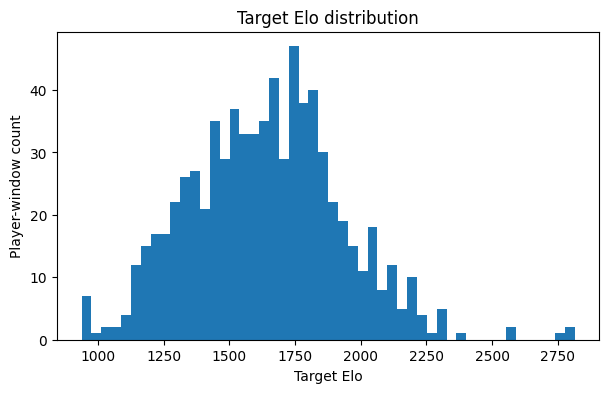

In [42]:
plt.figure(figsize=(7, 4))
plt.hist(model_df["target_elo"], bins=50)
plt.xlabel("Target Elo")
plt.ylabel("Player-window count")
plt.title("Target Elo distribution")
plt.show()

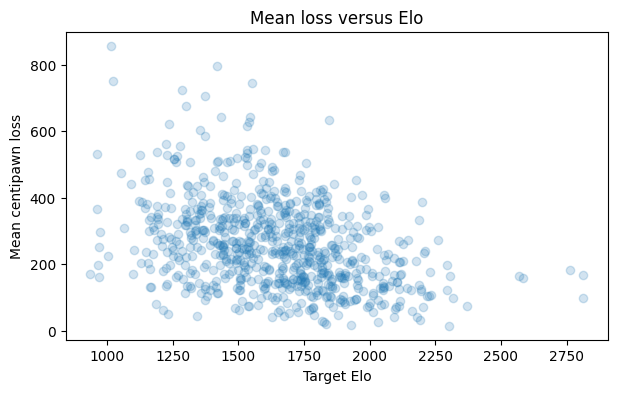

In [43]:
plt.figure(figsize=(7, 4))
plt.scatter(
  model_df["target_elo"],
  model_df["mean_loss_cp"],
  alpha=0.2,
)
plt.xlabel("Target Elo")
plt.ylabel("Mean centipawn loss")
plt.title("Mean loss versus Elo")
plt.show()

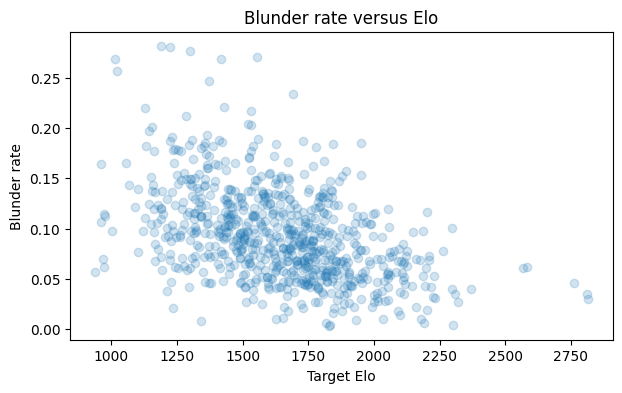

In [44]:
plt.figure(figsize=(7, 4))
plt.scatter(
  model_df["target_elo"],
  model_df["blunder_rate"],
  alpha=0.2,
)
plt.xlabel("Target Elo")
plt.ylabel("Blunder rate")
plt.title("Blunder rate versus Elo")
plt.show()

In [46]:
style_counts = (
  model_df
  .groupby("time_control")
  .size()
  .reset_index(name="n_rows")
  .sort_values("n_rows", ascending=False)
)

style_counts.head(20)

,time_control,n_rows
33,60+0,342
37,600+0,93
11,180+0,68
20,300+0,64
24,300+3,29
7,15+0,24
0,0+1,15
14,180+2,10
4,120+1,9
18,30+0,8


In [47]:
most_common_time_control = (
  model_df["time_control"]
  .value_counts()
  .idxmax()
)

most_common_time_control

'60+0'

In [48]:
style_df = model_df[
  model_df["time_control"] == most_common_time_control
].copy()

print("Selected time control:", most_common_time_control)
print("Rows:", len(style_df))
print("Unique players:", style_df["player"].nunique())

Selected time control: 60+0
Rows: 342
Unique players: 257


In [49]:
style_df[[
  "target_elo",
  "mean_opponent_elo",
  "mean_loss_cp",
  "median_loss_cp",
  "q90_loss_cp",
  "blunder_rate",
  "mistake_rate",
  "mean_clock_seconds",
]].describe()

,target_elo,mean_opponent_elo,mean_loss_cp,median_loss_cp,q90_loss_cp,blunder_rate,mistake_rate,mean_clock_seconds
count,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000
mean,1556.078363,1562.696784,309.260210,33.172368,572.881316,0.110680,0.238031,37.265322
std,277.408343,239.348854,132.654768,14.301370,417.228032,0.043286,0.066713,3.385838
min,936.800000,1093.700000,47.134164,10.400000,88.530000,0.017941,0.083206,27.062866
25%,1355.275000,1361.275000,220.686423,23.525000,263.787500,0.079161,0.189993,34.922352
50%,1539.650000,1571.000000,302.956053,30.350000,427.725000,0.105596,0.237010,36.676192
75%,1732.775000,1731.975000,380.749011,39.462500,785.075000,0.135849,0.279448,39.885249
max,2814.600000,2291.200000,795.860511,118.600000,2789.190000,0.281632,0.464141,46.041758


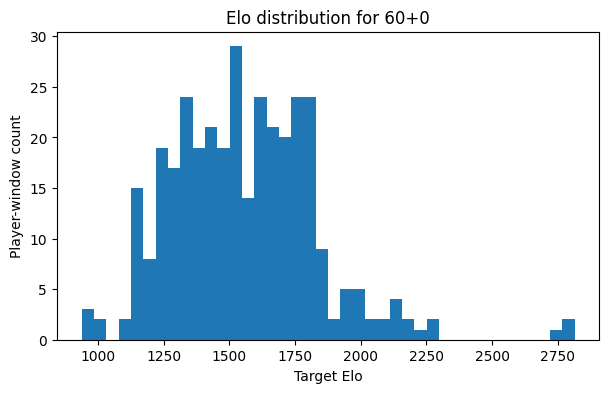

In [50]:
plt.figure(figsize=(7, 4))
plt.hist(style_df["target_elo"], bins=40)
plt.xlabel("Target Elo")
plt.ylabel("Player-window count")
plt.title(f"Elo distribution for {most_common_time_control}")
plt.show()

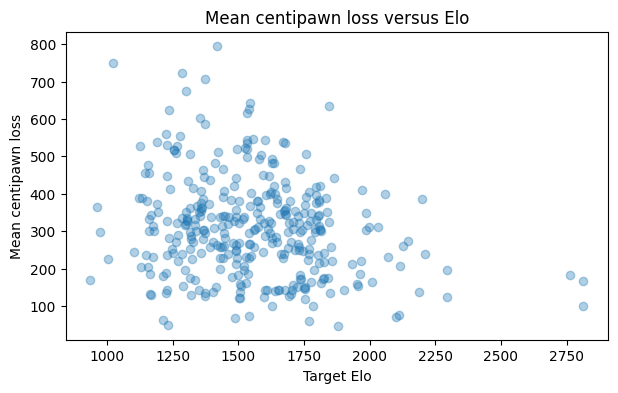

In [51]:
plt.figure(figsize=(7, 4))
plt.scatter(
  style_df["target_elo"],
  style_df["mean_loss_cp"],
  alpha=0.35,
)
plt.xlabel("Target Elo")
plt.ylabel("Mean centipawn loss")
plt.title("Mean centipawn loss versus Elo")
plt.show()

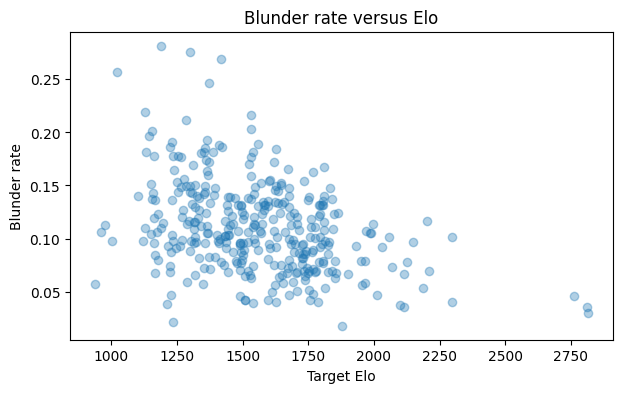

In [52]:
plt.figure(figsize=(7, 4))
plt.scatter(
  style_df["target_elo"],
  style_df["blunder_rate"],
  alpha=0.35,
)
plt.xlabel("Target Elo")
plt.ylabel("Blunder rate")
plt.title("Blunder rate versus Elo")
plt.show()

In [53]:
candidate_features = [
  "n_games",
  "n_moves",
  "mean_opponent_elo",
  "mean_score",
  "mean_loss_cp",
  "median_loss_cp",
  "q90_loss_cp",
  "max_loss_cp",
  "std_loss_cp",
  "inaccuracy_rate",
  "mistake_rate",
  "blunder_rate",
  "major_blunder_rate",
  "mean_clock_seconds",
  "min_clock_seconds",
  "low_time_rate",
  "very_low_time_rate",
  "mean_opening_loss_cp",
  "mean_middlegame_loss_cp",
  "mean_endgame_loss_cp",
]

In [54]:
feature_cols = [
  col for col in candidate_features
  if col in style_df.columns
]

feature_cols

['n_games',
 'n_moves',
 'mean_opponent_elo',
 'mean_score',
 'mean_loss_cp',
 'median_loss_cp',
 'q90_loss_cp',
 'max_loss_cp',
 'std_loss_cp',
 'inaccuracy_rate',
 'mistake_rate',
 'blunder_rate',
 'major_blunder_rate',
 'mean_clock_seconds',
 'min_clock_seconds',
 'low_time_rate',
 'very_low_time_rate',
 'mean_opening_loss_cp',
 'mean_middlegame_loss_cp',
 'mean_endgame_loss_cp']

In [55]:
model_ready_df = style_df[
  ["player", "target_elo"] + feature_cols
].copy()

model_ready_df = model_ready_df.replace([np.inf, -np.inf], np.nan)
model_ready_df = model_ready_df.dropna()

print("Rows after dropping NaNs:", len(model_ready_df))
print("Unique players:", model_ready_df["player"].nunique())

Rows after dropping NaNs: 329
Unique players: 252


In [56]:
from sklearn.model_selection import train_test_split

In [58]:
unique_players = (
  model_ready_df["player"]
  .dropna()
  .astype(str)
  .unique()
)

unique_players = np.array(unique_players)

train_players, test_players = train_test_split(
  unique_players,
  test_size=0.25,
  random_state=42,
)

train_df = model_ready_df[
  model_ready_df["player"].isin(train_players)
].copy()

test_df = model_ready_df[
  model_ready_df["player"].isin(test_players)
].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train players:", train_df["player"].nunique())
print("Test players:", test_df["player"].nunique())

Train rows: 254
Test rows: 75
Train players: 189
Test players: 63


In [59]:
X_train = train_df[feature_cols]
y_train = train_df["target_elo"]

X_test = test_df[feature_cols]
y_test = test_df["target_elo"]

In [60]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [62]:
baseline_pred = np.full(
  shape=len(y_test),
  fill_value=y_train.mean(),
)

baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_mse = mean_squared_error(
  y_test,
  baseline_pred,
)

baseline_rmse = np.sqrt(baseline_mse)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 210.06407349081363
Baseline RMSE: 270.2691570425534


In [63]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [64]:
ridge_model = make_pipeline(
  StandardScaler(),
  Ridge(alpha=10.0),
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(
  y_test,
  ridge_pred,
)
ridge_rmse = np.sqrt(ridge_mse)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)

Ridge MAE: 75.2467136554277
Ridge RMSE: 107.97066017707549


In [65]:
from sklearn.ensemble import RandomForestRegressor

In [67]:
rf_model = RandomForestRegressor(
  n_estimators=300,
  max_depth=5,
  min_samples_leaf=10,
  random_state=42,
  n_jobs=-1,
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(
  y_test,
  rf_pred,
)
rf_rmse = np.sqrt(rf_mse)

print("Random forest MAE:", rf_mae)
print("Random forest RMSE:", rf_rmse)

Random forest MAE: 91.59416743102716
Random forest RMSE: 136.586482665199


In [68]:
results_df = pd.DataFrame({
  "model": [
    "mean_baseline",
    "ridge",
    "random_forest",
  ],
  "mae": [
    baseline_mae,
    ridge_mae,
    rf_mae,
  ],
  "rmse": [
    baseline_rmse,
    ridge_rmse,
    rf_rmse,
  ],
})

results_df

,model,mae,rmse
0,mean_baseline,210.064073,270.269157
1,ridge,75.246714,107.970660
2,random_forest,91.594167,136.586483


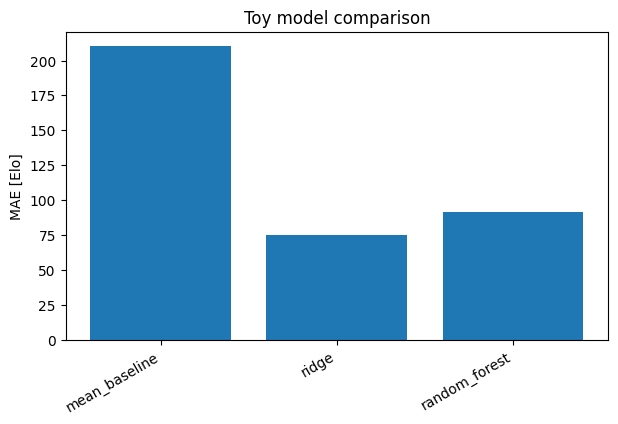

In [69]:
plt.figure(figsize=(7, 4))
plt.bar(results_df["model"], results_df["mae"])
plt.ylabel("MAE [Elo]")
plt.title("Toy model comparison")
plt.xticks(rotation=30, ha="right")
plt.show()

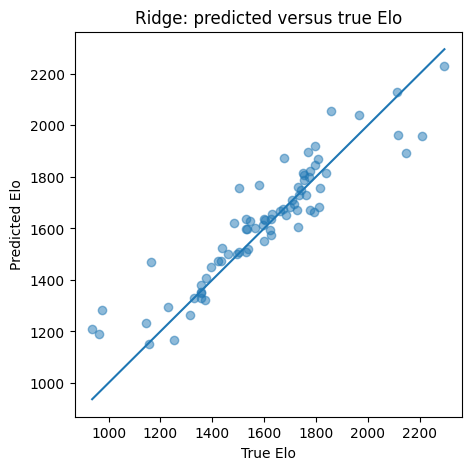

In [70]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, ridge_pred, alpha=0.5)
plt.xlabel("True Elo")
plt.ylabel("Predicted Elo")
plt.title("Ridge: predicted versus true Elo")

lims = [
  min(y_test.min(), ridge_pred.min()),
  max(y_test.max(), ridge_pred.max()),
]

plt.plot(lims, lims)
plt.show()

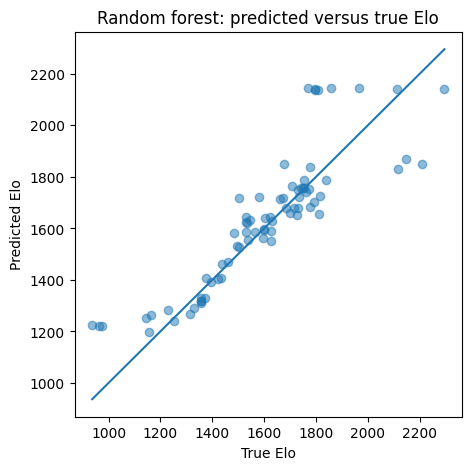

In [71]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel("True Elo")
plt.ylabel("Predicted Elo")
plt.title("Random forest: predicted versus true Elo")

lims = [
  min(y_test.min(), rf_pred.min()),
  max(y_test.max(), rf_pred.max()),
]

plt.plot(lims, lims)
plt.show()

In [72]:
test_eval_df = test_df.copy()
test_eval_df["ridge_pred"] = ridge_pred
test_eval_df["rf_pred"] = rf_pred

test_eval_df["ridge_residual"] = (
  test_eval_df["target_elo"] - test_eval_df["ridge_pred"]
)

test_eval_df["rf_residual"] = (
  test_eval_df["target_elo"] - test_eval_df["rf_pred"]
)

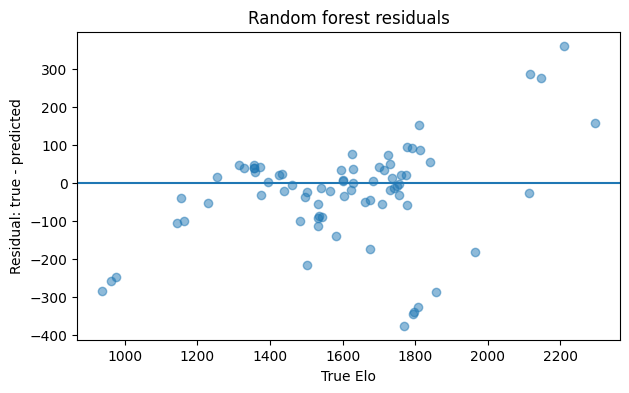

In [73]:
plt.figure(figsize=(7, 4))
plt.scatter(
  test_eval_df["target_elo"],
  test_eval_df["rf_residual"],
  alpha=0.5,
)
plt.axhline(0)
plt.xlabel("True Elo")
plt.ylabel("Residual: true - predicted")
plt.title("Random forest residuals")
plt.show()

In [74]:
importance_df = pd.DataFrame({
  "feature": feature_cols,
  "importance": rf_model.feature_importances_,
})

importance_df = importance_df.sort_values(
  "importance",
  ascending=False,
)

importance_df

,feature,importance
2,mean_opponent_elo,0.961945
3,mean_score,0.012428
1,n_moves,0.006392
5,median_loss_cp,0.003508
14,min_clock_seconds,0.002423
16,very_low_time_rate,0.002208
15,low_time_rate,0.001763
17,mean_opening_loss_cp,0.001471
13,mean_clock_seconds,0.001359
18,mean_middlegame_loss_cp,0.001252


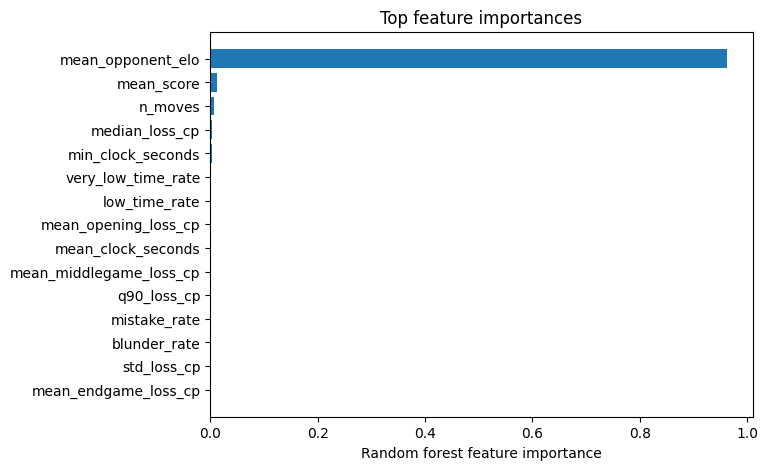

In [75]:
plt.figure(figsize=(7, 5))
plt.barh(
  importance_df["feature"].head(15)[::-1],
  importance_df["importance"].head(15)[::-1],
)
plt.xlabel("Random forest feature importance")
plt.title("Top feature importances")
plt.show()

In [76]:
feature_cols_no_opp = [
  col for col in feature_cols
  if col != "mean_opponent_elo"
]

In [77]:
X_train_no_opp = train_df[feature_cols_no_opp]
X_test_no_opp = test_df[feature_cols_no_opp]

In [78]:
rf_no_opp_model = RandomForestRegressor(
  n_estimators=300,
  max_depth=5,
  min_samples_leaf=10,
  random_state=42,
  n_jobs=-1,
)

rf_no_opp_model.fit(X_train_no_opp, y_train)

rf_no_opp_pred = rf_no_opp_model.predict(X_test_no_opp)

rf_no_opp_mae = mean_absolute_error(y_test, rf_no_opp_pred)
rf_no_opp_mse = mean_squared_error(
  y_test,
  rf_no_opp_pred,
)
rf_no_opp_rmse = np.sqrt(rf_no_opp_mse)

print("RF without opponent Elo MAE:", rf_no_opp_mae)
print("RF without opponent Elo RMSE:", rf_no_opp_rmse)

RF without opponent Elo MAE: 165.65453525433995
RF without opponent Elo RMSE: 222.6789508737277


In [79]:
pd.DataFrame({
  "model": [
    "mean_baseline",
    "rf_with_opponent_elo",
    "rf_without_opponent_elo",
  ],
  "mae": [
    baseline_mae,
    rf_mae,
    rf_no_opp_mae,
  ],
  "rmse": [
    baseline_rmse,
    rf_rmse,
    rf_no_opp_rmse,
  ],
})

,model,mae,rmse
0,mean_baseline,210.064073,270.269157
1,rf_with_opponent_elo,91.594167,136.586483
2,rf_without_opponent_elo,165.654535,222.678951
